# AI-Powered Financial Fraud Detection System

## Project Overview

This project demonstrates an end-to-end **financial fraud detection workflow** using Machine Learning and Natural Language Processing (NLP).

The system analyzes transaction information such as amount, transaction time, account history, device information, categorical transaction details, and a short transaction description.

The project uses a **simulated dataset created for educational purposes**. It is designed to demonstrate the complete ML workflow clearly and is **not a production banking system**.

### Project Objectives

- Understand and explore transaction data.
- Perform exploratory data analysis (EDA).
- Preprocess numerical, categorical, and text features.
- Convert transaction descriptions into numerical features using TF-IDF.
- Train a Random Forest classification model.
- Evaluate the model using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
- Visualize the Confusion Matrix and important features.
- Test the trained model on new transactions.
- Save the trained model and preprocessing objects for future use.

### Project Workflow

**Data Creation → Data Understanding → EDA → Train/Test Split → Preprocessing → NLP/TF-IDF → Feature Engineering → Model Training → Evaluation → Feature Importance → New Transaction Prediction → Model Saving → Conclusion**

## 1. Import Required Libraries

We use Pandas and NumPy for data handling, Matplotlib for visualization, and Scikit-learn for preprocessing, NLP, model training, and evaluation.

In [1]:
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Create a Simulated Financial Transaction Dataset

For this educational project, we create 10,000 simulated transactions.

A real fraud detection system should use a representative real-world dataset. The simulated data is useful here because it lets us demonstrate the complete workflow without requiring sensitive banking data.

In [2]:
np.random.seed(42)
n_samples = 10000

transaction_types = ["Purchase", "Transfer", "Withdrawal", "Payment"]
locations = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata"]
devices = ["Android", "iOS", "Windows", "Mac"]

normal_descriptions = [
    "normal purchase",
    "online shopping",
    "salary payment",
    "cash withdrawal",
    "bill payment"
]

suspicious_descriptions = [
    "urgent international payment from unknown device",
    "suspicious transaction",
    "unusual payment from new device"
]

amount = np.random.uniform(100, 100000, n_samples)
transaction_hour = np.random.randint(0, 24, n_samples)
international = np.random.binomial(1, 0.08, n_samples)
previous_transactions = np.random.randint(0, 20, n_samples)
account_age_days = np.random.randint(30, 3000, n_samples)
failed_attempts = np.random.poisson(0.5, n_samples).clip(0, 5)
new_device = np.random.binomial(1, 0.15, n_samples)
transaction_type = np.random.choice(transaction_types, n_samples)
location = np.random.choice(locations, n_samples)
device = np.random.choice(devices, n_samples)

# Create a fraud score from transaction characteristics.
fraud_score = (
    (amount > 70000).astype(int) * 2
    + (amount > 90000).astype(int)
    + (transaction_hour <= 4).astype(int) * 2
    + international * 2
    + (failed_attempts >= 3).astype(int) * 2
    + new_device * 2
    + (account_age_days < 120).astype(int)
)

# Convert score into a probability and sample the fraud label.
fraud_probability = 1 / (1 + np.exp(-(fraud_score - 5.5)))
fraud = np.random.binomial(1, fraud_probability)

# Make descriptions loosely reflect the generated class while keeping randomness.
description = [
    np.random.choice(suspicious_descriptions if label == 1 else normal_descriptions)
    for label in fraud
]

data = pd.DataFrame({
    "amount": amount,
    "transaction_hour": transaction_hour,
    "international": international,
    "previous_transactions": previous_transactions,
    "account_age_days": account_age_days,
    "failed_attempts": failed_attempts,
    "new_device": new_device,
    "transaction_type": transaction_type,
    "location": location,
    "device": device,
    "description": description,
    "fraud": fraud
})

print("Dataset created successfully!")
print("Dataset shape:", data.shape)
display(data.head())

Dataset created successfully!
Dataset shape: (10000, 12)


,amount,transaction_hour,international,previous_transactions,account_age_days,failed_attempts,new_device,transaction_type,location,device,description,fraud
0,37516.557873,22,0,4,1375,2,1,Payment,Bangalore,Android,bill payment,0
1,95076.359210,3,0,19,1998,1,1,Withdrawal,Delhi,Windows,normal purchase,0
2,73226.194787,17,0,11,1415,0,0,Payment,Kolkata,Windows,bill payment,0
3,59905.982571,4,1,19,2647,1,1,Transfer,Chennai,Windows,salary payment,0
4,15686.262180,15,0,19,1984,2,0,Transfer,Mumbai,iOS,normal purchase,0


## 3. Data Understanding

Before modeling, we inspect the dataset structure, data types, missing values, and class distribution.

In [3]:
print("Dataset Shape:")
print(data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nFraud Class Distribution:")
print(data["fraud"].value_counts().rename(index={0: "Legitimate", 1: "Fraud"}))

print(f"\nFraudulent Transactions: {data['fraud'].mean() * 100:.2f}%")

Dataset Shape:
(10000, 12)

Column Names:
['amount', 'transaction_hour', 'international', 'previous_transactions', 'account_age_days', 'failed_attempts', 'new_device', 'transaction_type', 'location', 'device', 'description', 'fraud']

Data Types:
amount                   float64
transaction_hour           int32
international              int32
previous_transactions      int32
account_age_days           int32
failed_attempts            int32
new_device                 int32
transaction_type             str
location                     str
device                       str
description                  str
fraud                      int32
dtype: object

Missing Values:
amount                   0
transaction_hour         0
international            0
previous_transactions    0
account_age_days         0
failed_attempts          0
new_device               0
transaction_type         0
location                 0
device                   0
description              0
fraud                    0
dt

## 4. Exploratory Data Analysis (EDA)

EDA helps us understand patterns in the transactions before training the model.

We will examine:

1. Legitimate vs. fraudulent transaction counts.
2. Transaction amount distribution.
3. Fraud distribution across transaction hours.
4. Average transaction amount by fraud class.

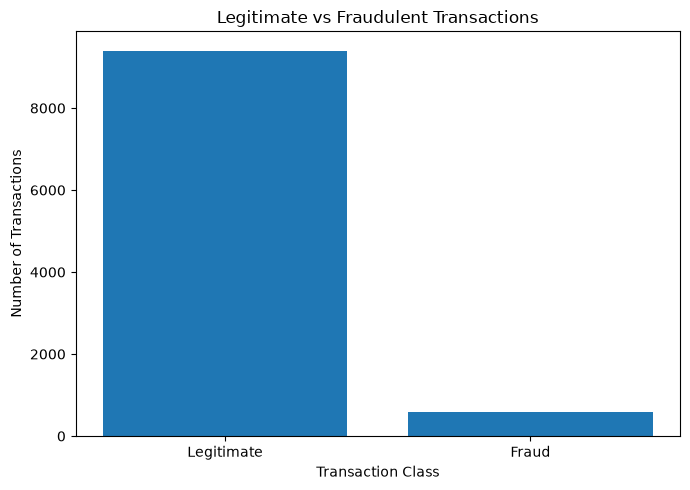

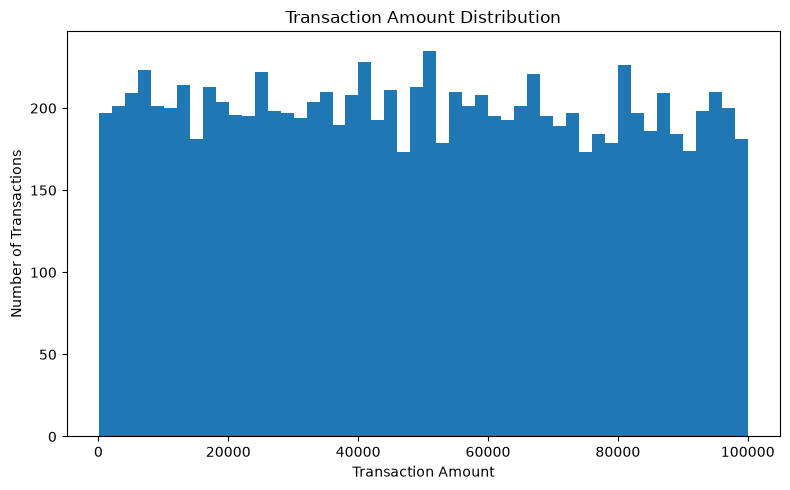

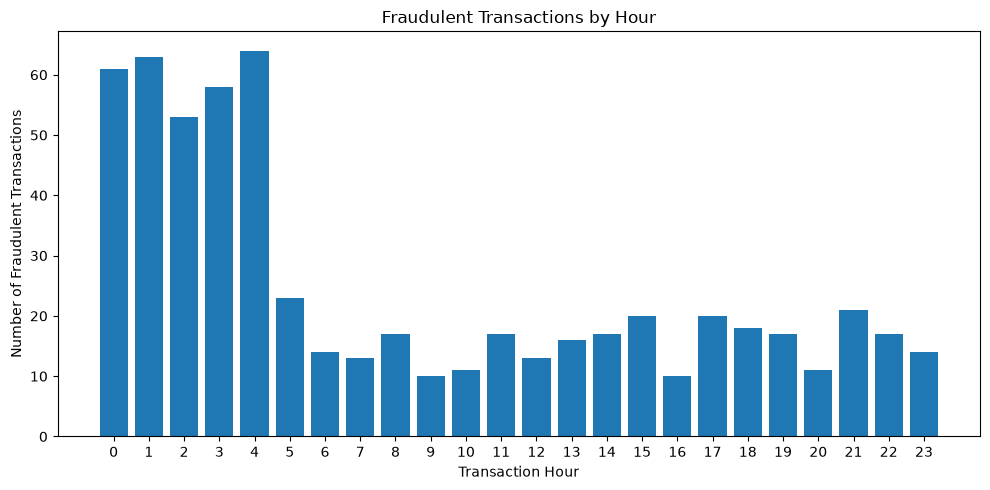

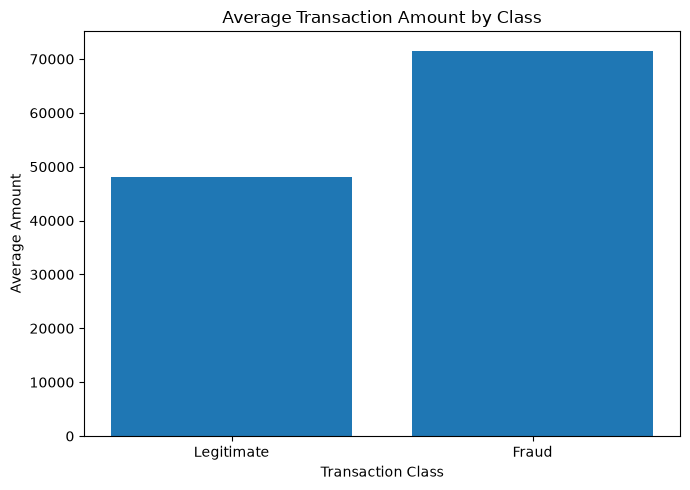

In [4]:
# 4.1 Legitimate vs Fraudulent Transactions
class_counts = data["fraud"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Legitimate", "Fraud"], [class_counts.get(0, 0), class_counts.get(1, 0)])
plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# 4.2 Transaction Amount Distribution
plt.figure(figsize=(8, 5))
plt.hist(data["amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# 4.3 Fraud Count by Transaction Hour
hour_fraud = data.groupby("transaction_hour")["fraud"].sum()

plt.figure(figsize=(10, 5))
plt.bar(hour_fraud.index, hour_fraud.values)
plt.title("Fraudulent Transactions by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Number of Fraudulent Transactions")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

# 4.4 Average Amount by Class
avg_amount = data.groupby("fraud")["amount"].mean()

plt.figure(figsize=(7, 5))
plt.bar(["Legitimate", "Fraud"], [avg_amount.get(0, 0), avg_amount.get(1, 0)])
plt.title("Average Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Average Amount")
plt.tight_layout()
plt.show()

### EDA Interpretation

The charts help us see whether transaction amount, transaction timing, and other behavioral patterns differ between legitimate and fraudulent transactions.

Because this dataset is simulated, these patterns are **illustrative rather than evidence about real banking behavior**. In a real project, conclusions should be based on a validated public or organizational dataset.

## 5. Train-Test Split

We split the raw data **before fitting any preprocessing or NLP transformer**. This is important because fitting preprocessing on the entire dataset can cause **data leakage** from the test set into training.

- **80% training data:** used to learn patterns.
- **20% testing data:** kept unseen until evaluation.

Stratification keeps the fraud/legitimate class ratio approximately consistent between the two sets.

In [5]:
train_df, test_df = train_test_split(
    data,
    test_size=0.20,
    random_state=42,
    stratify=data["fraud"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

y_train = train_df["fraud"]
y_test = test_df["fraud"]

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 8000
Testing samples: 2000

Training class distribution:
fraud
0    7522
1     478
Name: count, dtype: int64

Testing class distribution:
fraud
0    1880
1     120
Name: count, dtype: int64


## 6. Text Cleaning and NLP with TF-IDF

Transaction descriptions are text. Machine Learning models need numerical representations, so we clean the text and convert it into TF-IDF features.

**TF-IDF** gives higher importance to useful words while reducing the influence of very common words.

The vectorizer is fitted **only on training text** to avoid test-set leakage.

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_text = train_df["description"].apply(clean_text)
test_text = test_df["description"].apply(clean_text)

tfidf = TfidfVectorizer(
    max_features=100,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_text = tfidf.fit_transform(train_text)
X_test_text = tfidf.transform(test_text)

print("NLP vectorization completed!")
print("Training text features:", X_train_text.shape)
print("Testing text features:", X_test_text.shape)

NLP vectorization completed!
Training text features: (8000, 28)
Testing text features: (2000, 28)


## 7. Numerical and Categorical Preprocessing

We have three feature groups:

- **Numerical:** amount, transaction hour, account age, failed attempts, etc.
- **Categorical:** transaction type, location, and device.
- **Text:** transaction description represented using TF-IDF.

Numerical scaling and categorical encoding are fitted only on the training data.

In [7]:
numeric_columns = [
    "amount",
    "transaction_hour",
    "international",
    "previous_transactions",
    "account_age_days",
    "failed_attempts",
    "new_device"
]

categorical_columns = [
    "transaction_type",
    "location",
    "device"
]

scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(
    train_df[numeric_columns]
)

X_test_numeric = scaler.transform(
    test_df[numeric_columns]
)

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

X_train_categorical = encoder.fit_transform(
    train_df[categorical_columns]
)

X_test_categorical = encoder.transform(
    test_df[categorical_columns]
)

print("Numerical features:", len(numeric_columns))
print("Categorical features:", X_train_categorical.shape[1])
print("Text features:", X_train_text.shape[1])

Numerical features: 7
Categorical features: 13
Text features: 28


## 8. Combine All Features

We now combine numerical, categorical, and NLP features into one matrix for the Random Forest model.

In [8]:
X_train = hstack([
    csr_matrix(X_train_numeric),
    X_train_categorical,
    X_train_text
]).tocsr()

X_test = hstack([
    csr_matrix(X_test_numeric),
    X_test_categorical,
    X_test_text
]).tocsr()

print("Final training feature matrix:", X_train.shape)
print("Final testing feature matrix:", X_test.shape)

Final training feature matrix: (8000, 48)
Final testing feature matrix: (2000, 48)


## 9. Train the Random Forest Model

Random Forest is an ensemble classifier that combines many decision trees. It can capture non-linear relationships and is a useful baseline for tabular classification problems.

In [9]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest model...")
model.fit(X_train, y_train)
print("Model training completed successfully!")

Training Random Forest model...
Model training completed successfully!


## 10. Model Evaluation

We evaluate the model on the unseen test set.

- **Accuracy:** overall percentage of correct predictions.
- **Precision:** among transactions predicted as fraud, how many were actually fraud.
- **Recall:** among actual fraud cases, how many were detected.
- **F1 Score:** harmonic mean of precision and recall.
- **ROC-AUC:** measures ranking/discrimination ability across classification thresholds.

In [11]:
y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_probability)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

display(metrics_df.round(4))

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0
4,ROC-AUC,1.0


## 11. Classification Report and Confusion Matrix

The classification report provides class-wise precision, recall, and F1 score.

The confusion matrix shows:

- True Negatives (TN): legitimate transactions correctly identified.
- False Positives (FP): legitimate transactions incorrectly flagged as fraud.
- False Negatives (FN): fraud transactions missed by the model.
- True Positives (TP): fraud transactions correctly identified.

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1880
       Fraud       1.00      1.00      1.00       120

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



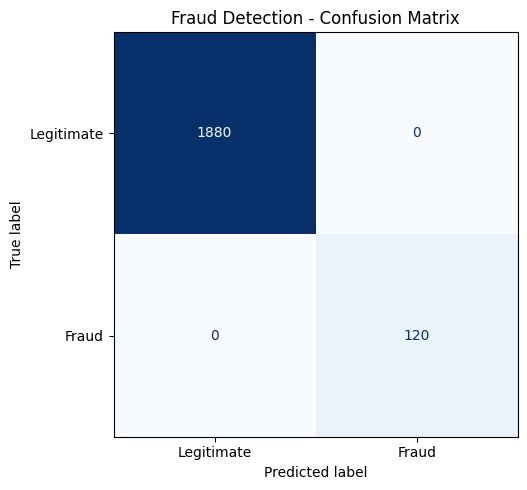

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraud"],
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
).plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
ax.set_title("Fraud Detection - Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Feature Importance

Random Forest provides an importance score for each input feature. This can help us understand which variables influenced the model most.

,Feature,Importance
22,device,0.139426
40,transaction,0.118504
38,suspicious,0.096650
39,suspicious transaction,0.084784
31,payment,0.069166
32,payment new,0.042565
24,international payment,0.038564
25,new,0.037349
26,new device,0.035772
46,urgent international,0.029296


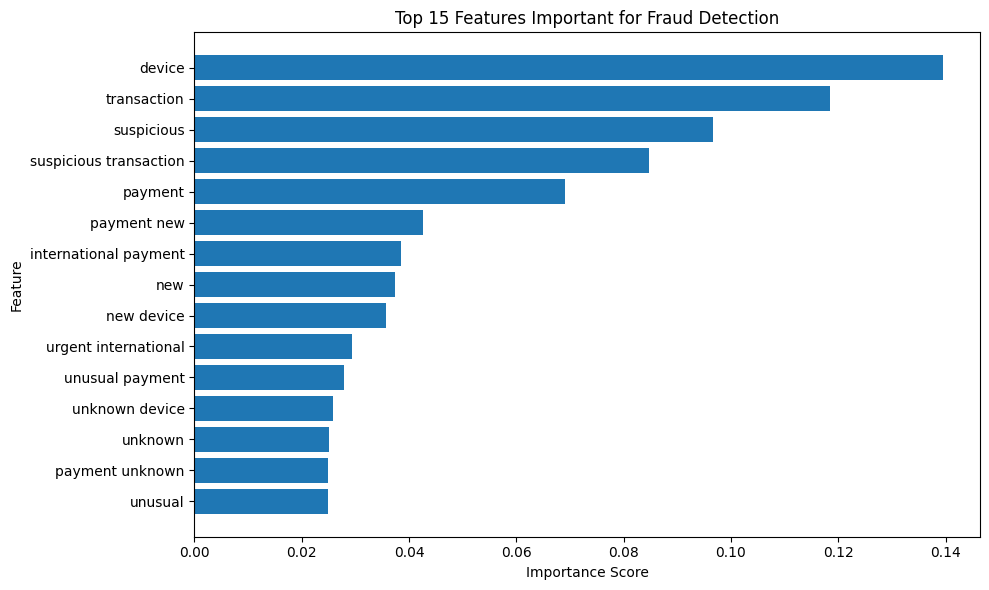

In [ ]:
categorical_feature_names = list(
    encoder.get_feature_names_out(categorical_columns)
)
text_feature_names = list(
    tfidf.get_feature_names_out()
)

feature_names = (
    numeric_columns
    + categorical_feature_names
    + text_feature_names
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

top_features = importance_df.head(15)

display(top_features)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)
plt.title("Top 15 Features Important for Fraud Detection")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 13. Live Fraud Prediction Function

The following function accepts a new transaction and applies the **same preprocessing learned from the training data** before making a prediction.

In [12]:
def predict_transaction(
    amount,
    transaction_hour,
    international,
    previous_transactions,
    account_age_days,
    failed_attempts,
    new_device,
    transaction_type,
    location,
    device,
    description
):
    new_row = pd.DataFrame([{
        "amount": amount,
        "transaction_hour": transaction_hour,
        "international": international,
        "previous_transactions": previous_transactions,
        "account_age_days": account_age_days,
        "failed_attempts": failed_attempts,
        "new_device": new_device,
        "transaction_type": transaction_type,
        "location": location,
        "device": device,
        "description": description
    }])

    new_numeric = scaler.transform(new_row[numeric_columns])
    new_categorical = encoder.transform(new_row[categorical_columns])
    new_text = tfidf.transform(new_row["description"].apply(clean_text))

    new_features = hstack([
        csr_matrix(new_numeric),
        new_categorical,
        new_text
    ]).tocsr()

    prediction = model.predict(new_features)[0]
    probability = model.predict_proba(new_features)[0, 1]

    result = "Fraudulent Transaction" if prediction == 1 else "Legitimate Transaction"

    print("=" * 55)
    print("TRANSACTION PREDICTION")
    print("=" * 55)
    print("Prediction:", result)
    print(f"Fraud Probability: {probability * 100:.2f}%")
    print("=" * 55)

    return prediction, probability

## 14. Test Case 1 — Suspicious Transaction

This example contains several suspicious characteristics. It is only a demonstration of how the prediction function works.

In [13]:
suspicious_prediction = predict_transaction(
    amount=75000,
    transaction_hour=2,
    international=1,
    previous_transactions=5,
    account_age_days=60,
    failed_attempts=4,
    new_device=1,
    transaction_type="Purchase",
    location="Mumbai",
    device="Android",
    description="urgent international payment from unknown device"
)

TRANSACTION PREDICTION
Prediction: Fraudulent Transaction
Fraud Probability: 100.00%


## 15. Test Case 2 — Legitimate Transaction

This example represents a routine transaction with less suspicious characteristics.

In [ ]:
legitimate_prediction = predict_transaction(
    amount=1200,
    transaction_hour=14,
    international=0,
    previous_transactions=15,
    account_age_days=900,
    failed_attempts=0,
    new_device=0,
    transaction_type="Purchase",
    location="Delhi",
    device="Android",
    description="normal grocery purchase"
)

TRANSACTION PREDICTION
Prediction: Legitimate Transaction
Fraud Probability: 4.50%


## 16. Prediction Comparison

The following table summarizes the two demonstration transactions.

In [ ]:
comparison = pd.DataFrame({
    "Transaction": ["Suspicious Transaction", "Legitimate Transaction"],
    "Amount": [75000, 1200],
    "International": ["Yes", "No"],
    "New Device": ["Yes", "No"],
    "Failed Attempts": [4, 0],
    "Description": [
        "Urgent international payment",
        "Normal grocery purchase"
    ]
})

display(comparison)

,Transaction,Amount,International,New Device,Failed Attempts,Description
0,Suspicious Transaction,75000,Yes,Yes,4,Urgent international payment
1,Legitimate Transaction,1200,No,No,0,Normal grocery purchase


## 17. Save the Model

We save the trained model and the preprocessing objects. Saving all of these together is important because future predictions must use the **same transformations** that were learned during training.

In [ ]:
MODEL_FILE = "fraud_detection_model.pkl"
VECTORIZER_FILE = "transaction_text_vectorizer.pkl"
SCALER_FILE = "transaction_scaler.pkl"
ENCODER_FILE = "transaction_encoder.pkl"

joblib.dump(model, MODEL_FILE)
joblib.dump(tfidf, VECTORIZER_FILE)
joblib.dump(scaler, SCALER_FILE)
joblib.dump(encoder, ENCODER_FILE)

print("Model and preprocessing files saved successfully!")

for file_name in [
    MODEL_FILE,
    VECTORIZER_FILE,
    SCALER_FILE,
    ENCODER_FILE
]:
    print("-", file_name)

Model and preprocessing files saved successfully!
- fraud_detection_model.pkl
- transaction_text_vectorizer.pkl
- transaction_scaler.pkl
- transaction_encoder.pkl


## 18. Project Limitations

This project is an educational demonstration using a simulated dataset.

The current results should **not** be interpreted as real-world banking performance. A production system would require a representative dataset, rigorous validation, security controls, monitoring, and domain-specific fraud investigation procedures.

Important future improvements include:

- Use a real public fraud dataset.
- Handle severe class imbalance carefully.
- Use cross-validation and hyperparameter tuning.
- Compare several classification algorithms.
- Add model explainability.
- Build a real-time API or Streamlit interface.
- Monitor model drift after deployment.

## 19. Conclusion

We built an end-to-end financial fraud detection workflow using Machine Learning and NLP.

The project covered:

- Dataset creation and understanding
- Exploratory Data Analysis
- Leakage-safe train/test splitting
- Numerical scaling
- Categorical encoding
- Text cleaning and TF-IDF
- Feature combination
- Random Forest training
- Model evaluation
- Confusion Matrix
- Feature importance
- New transaction prediction
- Model and preprocessing artifact saving

The main learning from this project is not only the final prediction, but the complete process of turning raw transaction information into a reproducible Machine Learning pipeline.

**Important:** The dataset is simulated, so the project should be described as an educational/prototype fraud detection system rather than a production banking model.